
# SVD and Cholesky decomposition of the ERI tensor as a matrix

For atomic-orbital (AO) basis functions $\{\chi_\mu\}$, the electron-repulsion integrals are

$$
(\mu\nu|\lambda\sigma)
=
\iint
\chi_\mu(\mathbf r_1)\chi_\nu(\mathbf r_1)
\frac{1}{r_{12}}
\chi_\lambda(\mathbf r_2)\chi_\sigma(\mathbf r_2)
\,d\mathbf r_1\,d\mathbf r_2.
$$

Using a composite AO-pair index $I=(\mu\nu)$ and $J=(\lambda\sigma)$, define the Coulomb/ERI matrix

$$
V_{IJ}=(\mu\nu|\lambda\sigma).
$$

Because this matrix is positive semidefinite in the Coulomb metric, it admits a low-rank representation of the form

$$
V \approx L L^T.
$$

This notebook computes $V$ with PySCF, examines its singular values, forms a Cholesky factor, and studies low-rank approximations obtained by retaining only the first few columns of $L$.


In [16]:

import numpy as np
from scipy.linalg.lapack import get_lapack_funcs
import matplotlib.pyplot as plt
from pyscf import gto

np.set_printoptions(precision=5, suppress=True)

def pivoted_cholesky(A, tol=1e-10):
    """
    Pivoted Cholesky decomposition of a positive semidefinite matrix.

    Returns
    -------
    L : ndarray
        Cholesky vectors in the original ordering, such that
            A ≈ L @ L.T

    Lp : ndarray
        Lower-triangular Cholesky factor in the pivoted ordering, such that
            A[piv][:, piv] ≈ Lp @ Lp.T

    piv : ndarray
        Pivot permutation.

    rank : int
        Numerical rank determined by LAPACK.
    """

    pstrf = get_lapack_funcs("pstrf", (A,))

    C, piv, rank, info = pstrf(
        A,
        lower=1,
        tol=tol
    )

    if info < 0:
        raise ValueError(f"LAPACK pstrf: illegal argument {-info}")

    # Convert LAPACK's 1-based indices to Python indexing
    piv = piv - 1

    # Cholesky factor in the pivoted ordering
    Lp = np.tril(C[:, :rank])

    # Transform back to the original ordering
    L = np.zeros_like(Lp)
    L[piv, :] = Lp

    return L, Lp, piv, rank



## 1. Molecule and AO basis

We use a water molecule in the minimal STO-3G basis. This gives a small example while still producing a nontrivial ERI matrix.


In [17]:

mol = gto.M(
    atom="""
    O  0.000000  0.000000  0.000000
    H  0.000000 -0.757000  0.587000
    H  0.000000  0.757000  0.587000
    """,
    basis="cc-pVTZ",
    unit="Angstrom",
    verbose=0,
)

nao = mol.nao_nr()
print(f"Number of AO basis functions: {nao}")


Number of AO basis functions: 58



## 2. Compute the four-index ERI tensor

`mol.intor("int2e")` returns the AO electron-repulsion tensor $(\mu\nu|\lambda\sigma)$.


In [18]:

eri = mol.intor("int2e")
print("ERI tensor shape:", eri.shape)


ERI tensor shape: (58, 58, 58, 58)



## 3. Build the ERI matrix $V$

The full $n_{\rm AO}^2 \times n_{\rm AO}^2$ supermatrix contains duplicate pair functions because $(\mu\nu)$ and $(\nu\mu)$ represent the same AO product. We therefore use only unique unordered AO pairs $\mu\ge\nu$.

The resulting matrix is

$$
V_{IJ}=(\mu\nu|\lambda\sigma),
\qquad I=(\mu\nu),\;J=(\lambda\sigma).
$$


In [19]:

# Unique AO pairs (mu, nu) with mu >= nu
pairs = [(mu, nu) for mu in range(nao) for nu in range(mu + 1)]
npair = len(pairs)

V = np.empty((npair, npair))
for I, (mu, nu) in enumerate(pairs):
    for J, (la, si) in enumerate(pairs):
        V[I, J] = eri[mu, nu, la, si]

# Remove tiny asymmetry from floating-point arithmetic.
V = 0.5 * (V + V.T)

print(f"Number of unique AO pairs: {npair}")
print("V shape:", V.shape)
print("Symmetric:", np.allclose(V, V.T))


Number of unique AO pairs: 1711
V shape: (1711, 1711)
Symmetric: True



## 4. Singular values of $V$

For a symmetric positive-semidefinite matrix, the singular values equal the nonnegative eigenvalues. Their decay reveals the numerical rank of the Coulomb matrix.


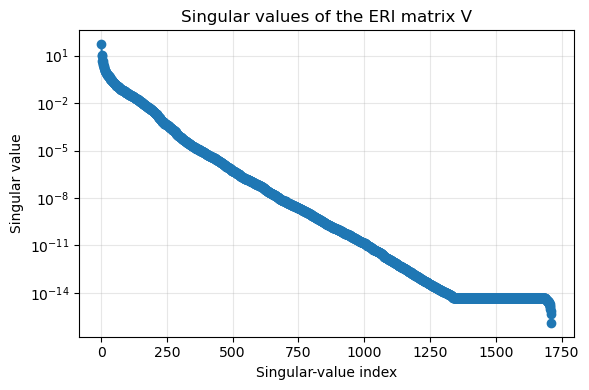

Largest singular value: 51.960749506595704
Smallest singular value: 1.2935388065074148e-16


In [20]:

U_svd, s, VT_svd = np.linalg.svd(V)

plt.figure(figsize=(6, 4))
plt.semilogy(np.arange(1, len(s) + 1), s, "o-")
plt.xlabel("Singular-value index")
plt.ylabel("Singular value")
plt.title("Singular values of the ERI matrix V")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("Largest singular value:", s[0])
print("Smallest singular value:", s[-1])



## 5. Cholesky decomposition

We seek

$$
V = L L^T.
$$

The Coulomb matrix is mathematically positive semidefinite rather than guaranteed to be strictly positive definite. If roundoff produces a tiny non-positive eigenvalue, a negligible diagonal shift is added so that the standard dense Cholesky routine can proceed.


In [21]:
L, Lp, piv, rank = pivoted_cholesky(V, tol=1e-8)

#L, rank, piv = pivoted_cholesky(V, tol=1e-8)

V_chol = L @ L.T

print("Cholesky rank:", rank)
print("Max error:",
      np.max(np.abs(V - V_chol)))




Cholesky rank: 664
Max error: 9.971064311026234e-09



## 6. Error as a function of retained Cholesky columns

For completeness, we can repeat the truncation for every possible rank and monitor the maximum absolute matrix-element error.


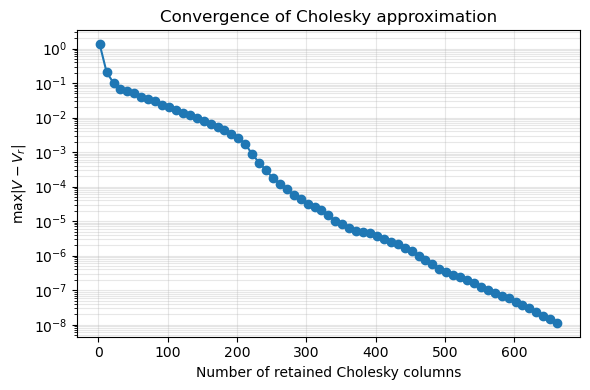

In [22]:

errors = []
r_range = np.arange(1, rank, 10)
for r_test in r_range:
    Lr = L[:, :r_test]
    Vr = Lr @ Lr.T
    errors.append(np.max(np.abs(V - Vr)))
    

plt.figure(figsize=(6, 4))
plt.semilogy(1 + r_range, errors, "o-")
plt.xlabel("Number of retained Cholesky columns")
plt.ylabel(r"$\max |V - V_r|$")
plt.title("Convergence of Cholesky approximation")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
# hmm